In [1]:
!nvidia-smi

Wed Mar 25 18:12:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |   13877MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import keras as kr
from keras import layers
import seaborn as sb
import sklearn
import tensorflow as tf
import random as rnd
import math
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sklearn.set_config(transform_output="pandas")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/My Drive/waste-clasifier/

/content/drive/My Drive/waste-clasifier


In [4]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

In [5]:
train_csv=pd.read_csv("train/_classes.csv")
train_df=pd.DataFrame(train_csv)
#train_ppc_csv=pd.read_csv("train_preprocessed/_classes_preprocessed.csv")
#train_ppc_df=pd.DataFrame(train_ppc_csv)
test_csv=pd.read_csv("test/_classes.csv")
test_df=pd.DataFrame(test_csv)
valid_csv=pd.read_csv("valid/_classes.csv")
valid_df=pd.DataFrame(valid_csv)

y_train = train_df[classes].values
y_val = valid_df[classes].values
y_test = test_df[classes].values
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1767 entries, 0 to 1766
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filename   1767 non-null   object
 1   cardboard  1767 non-null   int64 
 2   glass      1767 non-null   int64 
 3   metal      1767 non-null   int64 
 4   paper      1767 non-null   int64 
 5   plastic    1767 non-null   int64 
 6   trash      1767 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 96.8+ KB


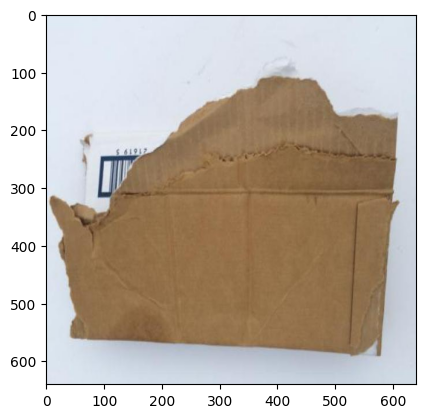

In [7]:
random_idx = rnd.randint(0, len(train_df) - 1)
img_path = os.path.join("train", train_df["filename"][random_idx])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [8]:
vis_df=pd.DataFrame({
    "train":train_df[classes].sum(),
    "test":test_df[classes].sum(),
    "valid":valid_df[classes].sum()
})
vis_df

,train,test,valid
cardboard,275,44,84
glass,352,47,102
metal,284,40,85
paper,423,64,107
plastic,340,44,96
trash,93,14,30


In [7]:
df_plot = vis_df.reset_index().rename(columns={'index': 'category'})
df_melted = df_plot.melt(id_vars='category', var_name='dataset', value_name='count')
sb.barplot(data=df_melted, x='category', y='count', hue='dataset')

NameError: name 'vis_df' is not defined

In [24]:
datagen = ImageDataGenerator(rescale=1./255)
image_size=256
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="train/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=1,
    class_mode="raw"
)

Found 1767 validated image filenames.


In [22]:
v_size=256
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory="valid/",
    x_col=valid_df.columns[0],
    y_col=classes,
    target_size=(v_size, v_size),
    batch_size=1,
    class_mode="raw"
)

Found 504 validated image filenames.


In [23]:
t_size=256
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="test/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(t_size, t_size),
    batch_size=1,
    class_mode="raw",
    shuffle=False
)

Found 253 validated image filenames.


In [10]:
from sklearn.utils.class_weight import compute_class_weight

one_hot_labels = train_df[classes].values 
print(one_hot_labels)

train_classes_int = np.argmax(one_hot_labels, axis=1)
print(train_classes_int)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_int),
    y=train_classes_int
)

class_weights_dict = dict(enumerate([x for x in class_weights_array]))
print(sum(class_weights_dict))

print("Wyliczone wagi klas:", class_weights_dict)

[[0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 ...
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]
[3 3 3 ... 0 0 0]
15
Wyliczone wagi klas: {0: np.float64(1.0709090909090908), 1: np.float64(0.8366477272727273), 2: np.float64(1.0369718309859155), 3: np.float64(0.6962174940898345), 4: np.float64(0.8661764705882353), 5: np.float64(3.1666666666666665)}


In [11]:
image_size=256
target_size=256
rotations=4
input=layers.Input((image_size,image_size,3))

ll=layers.Lambda(lambda t: tf.repeat(t[:, tf.newaxis, ...], repeats=rotations, axis=1))

ppc1=layers.RandomFlip(mode="horizontal_and_vertical")
ppc2=layers.RandomRotation(factor=(0.0, 1.0),fill_mode='reflect',interpolation='bilinear')

#ppc3=layers.Resizing(target_size,target_size)

a_0=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_1a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_1a=layers.Conv2D(6, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_1a=layers.Conv2D(6, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_1a=layers.Concatenate(axis=-1)
c7_1b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_1b=layers.Conv2D(6, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_1b=layers.Conv2D(6, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_1b=layers.Concatenate(axis=-1)
b_1=layers.BatchNormalization()
p_1=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_1=layers.Concatenate(axis=-1)

a_1=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")


c7_2a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_2a=layers.Conv2D(8, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_2a=layers.Conv2D(12, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_2a=layers.Concatenate(axis=-1)
c7_2b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_2b=layers.Conv2D(8, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_2b=layers.Conv2D(12, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_2b=layers.Concatenate(axis=-1)
b_2=layers.BatchNormalization()
p_2=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_2=layers.Concatenate(axis=-1)

a_2=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_3a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_3a=layers.Conv2D(10, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_3a=layers.Conv2D(18, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_3a=layers.Concatenate(axis=-1)
c7_3b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_3b=layers.Conv2D(10, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_3b=layers.Conv2D(18, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_3b=layers.Concatenate(axis=-1)
b_3=layers.BatchNormalization()
p_3=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_3=layers.Concatenate(axis=-1)

a_3=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_4a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_4a=layers.Conv2D(12, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_4a=layers.Conv2D(24, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_4a=layers.Concatenate(axis=-1)
c7_4b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_4b=layers.Conv2D(12, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_4b=layers.Conv2D(24, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_4b=layers.Concatenate(axis=-1)
b_4=layers.BatchNormalization()
p_4=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_4=layers.Concatenate(axis=-1)

a_4=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_5a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_5a=layers.Conv2D(14, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_5a=layers.Conv2D(30, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_5a=layers.Concatenate(axis=-1)
c7_5b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_5b=layers.Conv2D(14, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_5b=layers.Conv2D(30, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_5b=layers.Concatenate(axis=-1)
b_5=layers.BatchNormalization()
p_5=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_5=layers.Concatenate(axis=-1)

a_5=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_6a=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_6a=layers.Conv2D(14, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_6a=layers.Conv2D(30, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_6a=layers.Concatenate(axis=-1)
c7_6b=layers.Conv2D(4, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_6b=layers.Conv2D(14, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_6b=layers.Conv2D(30, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_6b=layers.Concatenate(axis=-1)
b_6=layers.BatchNormalization()
p_6=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_6=layers.Concatenate(axis=-1)

final_avg=layers.GlobalAveragePooling2D(data_format="channels_last")

fl=layers.Flatten()

drop1=layers.Dropout(0.3)

dense1=layers.Dense(200,activation="softplus")
dense2=layers.Dense(100,activation="tanh")

drop2=layers.Dropout(0.15)
        
softmax=layers.Dense(6, activation="softmax")

avg_last=layers.GlobalAveragePooling1D()

In [12]:
def conv_part_model():
    image=layers.Input((image_size,image_size,3))

    #ppc=ppc3(ppc2(ppc1(image)))
    ppc=ppc2(ppc1(image))
    avg_0=a_0(ppc)

    conv_1a=conc_1a([c7_1a(ppc),c5_1a(ppc),c3_1a(ppc)])
    conv_1b=conc_1b([conv_1a,c7_1b(conv_1a),c5_1b(conv_1a),c3_1b(conv_1a)])
    pool_1=p_1(b_1(conv_1b))
    merge_1=m_1([avg_0,pool_1])
    avg_1=a_1(merge_1)

    conv_2a=conc_2a([c7_2a(merge_1),c5_2a(merge_1),c3_2a(merge_1)])
    conv_2b=conc_2b([conv_2a,c7_2b(conv_2a),c5_2b(conv_2a),c3_2b(conv_2a)])
    pool_2=p_2(b_2(conv_2b))
    merge_2=m_2([avg_1,pool_2])
    avg_2=a_2(merge_2)

    conv_3a=conc_3a([c7_3a(merge_2),c5_3a(merge_2),c3_3a(merge_2)])
    conv_3b=conc_3b([conv_3a,c7_3b(conv_3a),c5_3b(conv_3a),c3_3b(conv_3a)])
    pool_3=p_3(b_3(conv_3b))
    merge_3=m_3([avg_2,pool_3])
    avg_3=a_3(merge_3)

    conv_4a=conc_4a([c7_4a(merge_3),c5_4a(merge_3),c3_4a(merge_3)])
    conv_4b=conc_4b([conv_4a,c7_4b(conv_4a),c5_4b(conv_4a),c3_4b(conv_4a)])
    pool_4=p_4(b_4(conv_4b))
    merge_4=m_4([avg_3,pool_4])
    avg_4=a_4(merge_4)

    conv_5a=conc_5a([c7_5a(merge_4),c5_5a(merge_4),c3_5a(merge_4)])
    conv_5b=conc_5b([conv_5a,c7_5b(conv_5a),c5_5b(conv_5a),c3_5b(conv_5a)])
    pool_5=p_5(b_5(conv_5b))
    merge_5=m_5([avg_4,pool_5])
    avg_5=a_5(merge_5)

    conv_6a=conc_6a([c7_6a(merge_5),c5_6a(merge_5),c3_6a(merge_5)])
    conv_6b=conc_6b([conv_6a,c7_6b(conv_6a),c5_6b(conv_6a),c3_6b(conv_6a)])
    pool_6=p_6(b_6(conv_6b))
    merge_6=m_6([avg_5,pool_6])
    
    avg_final=final_avg(merge_6)

    #flat=drop1(fl(avg_4))

    post_dense=drop2(dense2(dense1(avg_final)))

    out_softmax=softmax(post_dense)

    return kr.Model(inputs=image, outputs=out_softmax)

In [13]:
multi_image=ll(input)

conv_part=conv_part_model()

multi_softmax=layers.TimeDistributed(conv_part)(multi_image)
output=avg_last(multi_softmax)

In [15]:
model=kr.Model(inputs=input,outputs=output)
model.build((image_size,image_size,3))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 4, 256, 256, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 4, 6)           │       874,322 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 874,322 (3.34 MB)

 Trainable params: 873,490 (3.33 MB)

 Non-trainable params: 832 (3.25 KB)

In [16]:
conv_part.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 256, 256,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        592 │ random_rotation[… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │        456 │ random_rotation[… │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │        168 │ random_rotation[… │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 16)               │            │ conv2d_1[0][0],   │
│                     │                   │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │      3,140 │ concatenate[0][0] │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │      2,406 │ concatenate[0][0] │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │        870 │ concatenate[0][0] │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 32)               │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 128, 128,  │          0 │ random_rotation[… │
│ (AveragePooling2D)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ average_pooling2… │
│ (Concatenate)       │ 35)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      6,864 │ concatenate_2[0]

 Total params: 874,322 (3.34 MB)

 Trainable params: 873,490 (3.33 MB)

 Non-trainable params: 832 (3.25 KB)

In [13]:
model_load = kr.models.load_model(
    "mikro_model50.keras"
    #custom_objects={"full_attention_block": full_attention_block
                    #,"loss":get_sparse_weighted_loss
                    #}
)

In [14]:
model_load.summary()

NameError: name 'model_load' is not defined

In [25]:
epochs = 50
Adam = kr.optimizers.Adam(learning_rate=0.001)
r_lr=kr.callbacks.ReduceLROnPlateau(patience=2, monitor="val_accuracy",factor=0.7)
e_s=kr.callbacks.EarlyStopping(patience=10, monitor="val_accuracy")
model.compile(optimizer=Adam,loss="categorical_crossentropy",metrics =['accuracy','recall','precision'])
model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[r_lr,e_s],
    validation_data=valid_generator,
    class_weight=class_weights_dict
)

Epoch 1/50
1767/1767 ━━━━━━━━━━━━━━━━━━━━ 254s 127ms/step - accuracy: 0.1783 - loss: 1.8951 - precision: 0.1053 - recall: 0.0011 - val_accuracy: 0.2123 - val_loss: 1.8450 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
1767/1767 ━━━━━━━━━━━━━━━━━━━━ 256s 127ms/step - accuracy: 0.1964 - loss: 1.8563 - precision: 0.3404 - recall: 0.0091 - val_accuracy: 0.2619 - val_loss: 1.9760 - val_precision: 0.2062 - val_recall: 0.1310 - learning_rate: 0.0010
Epoch 3/50
1767/1767 ━━━━━━━━━━━━━━━━━━━━ 226s 128ms/step - accuracy: 0.2337 - loss: 1.8255 - precision: 0.5352 - recall: 0.0215 - val_accuracy: 0.2798 - val_loss: 1.9072 - val_precision: 0.3793 - val_recall: 0.1310 - learning_rate: 0.0010
Epoch 4/50
1767/1767 ━━━━━━━━━━━━━━━━━━━━ 227s 128ms/step - accuracy: 0.2666 - loss: 1.7555 - precision: 0.6243 - recall: 0.0640 - val_accuracy: 0.1786 - val_loss: 2.8121 - val_precision: 0.1658 - val_recall: 0.1290 - learning_rate: 0.0010
Epoch 5/50
1767/1767 ━━━━━━━━━━━

KeyboardInterrupt: 

In [20]:
model.evaluate(test_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 53s 7s/step - accuracy: 0.7589 - loss: 0.7927 - precision: 0.7759 - recall: 0.7391


[0.7926552295684814, 0.7588932514190674, 0.739130437374115, 0.7759336233139038]

In [19]:
model.save('multirot_model37.keras')

In [ ]:

"""
multirot_model37 | accuracy: 0.7589 - loss: 0.7927 - precision: 0.7759 - recall: 0.7391
best_model50 | accuracy: 0.7233 - loss: 0.8908 - precision: 0.7816 - recall: 0.6364
big_rot_model62 | accuracy: 0.7036 - loss: 0.9047 - precision: 0.7703 - recall: 0.6364
big_rot_model50 | accuracy: 0.7154 - loss: 0.9060 - precision: 0.7740 - recall: 0.6364
holded_rot_model50 | accuracy: 0.6561 - loss: 0.9801 - precision: 0.7039 - recall: 0.5731
goat_model_50 | accuracy: 0.7352 - loss: 0.7235 - precision: 0.8128 - recall: 0.7036
too_long_model42 | accuracy: 0.5929 - loss: 1.1717 - precision: 0.7365 - recall: 0.4308
next3_model43 | accuracy: 0.6482 - loss: 1.0186 - precision: 0.7182 - recall: 0.6245
next2_model34 | accuracy: 0.6640 - loss: 1.0755 - precision: 0.7257 - recall: 0.6482
next_model38 | accuracy: 0.6719 - loss: 1.0829 - precision: 0.7124 - recall: 0.6364
thing_model38 | accuracy: 0.6561 - loss: 1.0464 - precision: 0.7182 - recall: 0.6245
gigant3_model42 | accuracy: 0.6719 - loss: 0.9546 - precision: 0.7212 - recall: 0.5929 - 256
gigant2_model38 | accuracy: 0.6087 - loss: 1.0791 - precision: 0.6837 - recall: 0.5296 - 256
gigant_model47 | accuracy: 0.6443 - loss: 0.9469 - precision: 0.7311 - recall: 0.6126 - 256
ballanced2_model47 | accuracy: 0.6522 - loss: 1.0356 - precision: 0.7436 - recall: 0.5731 - 256
ballanced_model34 | accuracy: 0.6561 - loss: 1.0261 - precision: 0.7346 - recall: 0.6126 - 128
overfitted_model23 | accuracy: 0.6245 - loss: 1.3682 - precision: 0.6565 - recall: 0.5968 - 128
mikro_model50 | accuracy: 0.6877 - loss: 0.9676 - precision: 0.7451 - recall: 0.6008 - 128
mikro_model67 | accuracy: 0.6759 - loss: 0.9928 - precision: 0.7299 - recall: 0.6087 - 128
good_model1 | accuracy: 0.2530 - loss: 2.6561 - precision: 0.2530 - recall: 0.2530 - 128
good_model2 | accuracy: 0.3439 - loss: 2.1603 - precision: 0.3798 - recall: 0.3123 - 128
bigger_good_model50 | accuracy: 0.6877 - loss: 0.9277 - precision: 0.7273 - recall: 0.6324 - 128
cnn_mini1 | accuracy: 0.2530 - loss: 1.7233 - precision: 0.0000e+00 - recall: 0.0000e+00 - 128
cnn_test1 | accuracy: 0.1779 - loss: 10.2570 - precision: 0.2003 - recall: 0.6008 - 128
cnn_test2 | accuracy: 0.1581 - loss: 6.6893 - precision: 0.2055 - recall: 0.4111 - 128
idk_model50 | accuracy: 0.5850 - loss: 1.1330 - precision: 0.7634 - recall: 0.3953 - 128
sml_model46 | accuracy: 0.6522 - loss: 0.9800 - precision: 0.7225 - recall: 0.5968 - 128
sml_model50 | accuracy: 0.6245 - loss: 1.0281 - precision: 0.7020 - recall: 0.5494 - 128






"""

In [21]:
def visualize_random_prediction(model, generator, class_labels):
    # Pobranie jednego batcha (paczki) danych z generatora
    x_batch, y_batch = next(iter(generator))
    
    # Wylosowanie pojedynczego obrazka z pobranego batcha
    idx = np.random.randint(0, len(x_batch))
    img = x_batch[idx]
    true_labels = y_batch[idx]
    
    # Odczytanie prawdziwej klasy
    # Zakładamy wektor np. [0, 1, 0, 0, 0, 0] na podstawie Twojego class_mode="raw"
    true_class_idx = np.argmax(true_labels)
    true_class_name = class_labels[true_class_idx]
    
    # Wykonanie predykcji przez model
    # Używamy expand_dims, aby zmienić kształt z (256, 256, 3) na (1, 256, 256, 3)
    pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    
    # Odczytanie przewidzianej klasy i prawdopodobieństwa softmax
    pred_class_idx = np.argmax(pred_probs)
    pred_class_name = class_labels[pred_class_idx]
    pred_prob = pred_probs[pred_class_idx]
    
    # --- Wyświetlanie obrazka ---
    plt.figure(figsize=(6, 6))
    
    # Zabezpieczenie na wypadek różnych metod normalizacji obrazu
    img_to_show = img
    if img.max() > 1.0:
        img_to_show = img.astype('uint8') # Jeśli wartości to [0-255]
    elif img.min() < 0:
        # Jeśli użyto preprocessingu np. z ResNet/Inception (wartości np. [-1, 1])
        img_to_show = (img - img.min()) / (img.max() - img.min()) 
        
    plt.imshow(img_to_show)
    
    # Kolor tekstu zależny od poprawności predykcji
    text_color = 'green' if true_class_idx == pred_class_idx else 'red'
    
    plt.title(
        f"Realna: {true_class_name}\n"
        f"Przewidziana: {pred_class_name} ({pred_prob:.2%})", 
        color=text_color, 
        fontweight='bold',
        fontsize=14
    )
    
    plt.axis('off')
    plt.show()

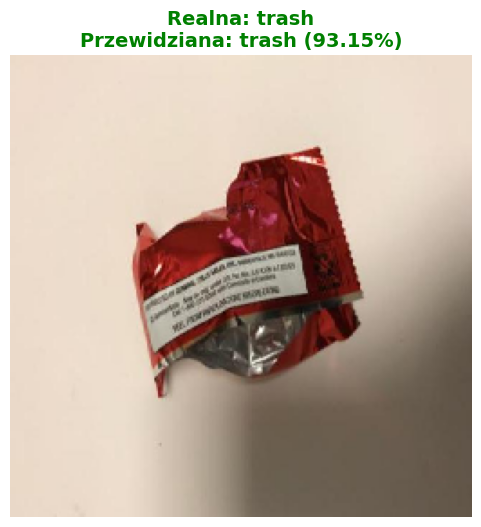

In [49]:
visualize_random_prediction(model, test_generator, classes)

In [52]:
print(y_test)

[[0 1 0 0 0 0]
 [0 0 0 1 0 0]
 [0 1 0 0 0 0]
 ...
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 1 0 0 0 0]]


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step


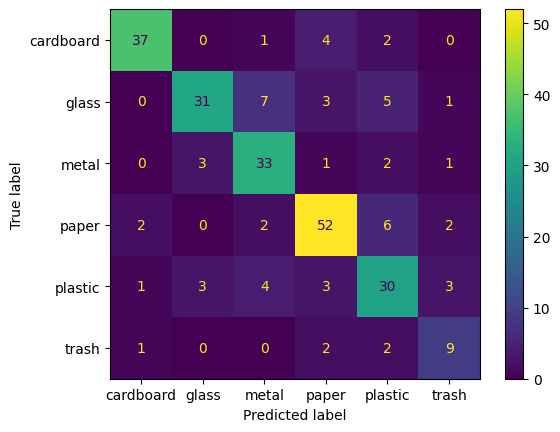

In [73]:
real=[np.argmax(x) for x in y_test]
pred=[np.argmax(x) for x in model.predict(test_generator)]
confusion_matrix=sklearn.metrics.confusion_matrix(real, pred)
disp=sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix,display_labels=classes)
disp.plot()
plt.show()